## IMPORTS

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt






## LOADING DATA


In [2]:
df_reviews = pd.read_json('/Users/spennyfinn/Documents/Projects/NLP/data/yelp_academic_dataset_review.json', lines=True)
df_businesses = pd.read_json('/Users/spennyfinn/Documents/Projects/NLP/data/yelp_academic_dataset_business.json', lines=True)

## EDA

In [3]:
df_reviews.head(5)

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


In [4]:
df_reviews.sample(10)

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
412350,-8E9ypGI-CuNekH9KI0-9w,eo_mnkeEp0ygMXpD6b_vWg,dpdiIXeYhGGsSvfBZHROEw,1,0,0,0,Express Scripts is absolutely incompetent. Th...,2013-12-28 16:15:14
5272090,N3D7Er47EGEp1H6_pN_XXQ,8h8mzXUou7PBrd22XfoawA,V7PzZzhM8HAFX6sNmadNuA,1,0,0,0,Usually love Taco Bus. Ordered two burritos t...,2018-12-10 01:33:03
687578,5kvECtNkMeRdtNfDj9vmVw,HNfAI9LTapxcal71bRQn2A,Zi-F-YvyVOK0k5QD7lrLOg,5,0,0,0,Muriel's was well worth the 1.5 hour wait. We...,2021-06-16 23:10:02
3805258,-yFnHe-rhMnWMggtbJTUJg,H-yW58-_agsHxFVPD4YVNg,L9wEU391_zUl9eWe7RtxKQ,5,0,0,0,The only thing missing is their lack of making...,2015-11-12 21:01:31
6291219,Pub7Qp3jTbQ6gaUbvLB5Nw,hptOlUT1IvCNf1PvgotsOA,iRIHK8-EwpeffwvoO4nzIA,5,0,0,0,This unassuming place has great atmosphere onl...,2016-01-17 11:48:18
3093845,3esLMBOF6981ZmKJtmwVpg,A9cXP_K95FRor1qxuUEu2g,sRxIL_d1ygEtLoHvGs6N_Q,3,2,0,0,"On my third visit to Monical's Pizza, the Glen...",2015-01-02 19:38:39
5208083,jGHGkmerVp4kM0kagR1uiw,9Xb8t1EYpZazD9GhvHPjpw,8YDJraW_cg5IPTPisPfB-A,5,0,0,0,This place is hands down one of my favorite pl...,2018-11-19 21:55:48
4850738,iTZ-5LBpCEgy7sHjgzE8ow,6qgHw2J-2T_KCVLQTRqv9Q,sihT-_DtwOdnDDDJbXN22A,5,2,0,2,A must visit if you're ever in Florida. Cigar ...,2016-09-14 22:20:15
5634279,vO8FjHlQiOOtTCVVAK1NBQ,vYMvOTL31e0KbTo9Hd0tjg,cdZK0SK2CskMWDcvmH4wwg,4,2,1,5,Good soft serve and Italian ice shop. You can ...,2015-12-09 02:17:10
6163877,6B_-l6FUf6YhAsEND8xoZQ,cIwQn8lwLMzxtevUn0nF2A,yyYZjAQRfHuBh7TNW3Fkkg,1,0,0,0,Moo Hope? More like Noo Hope! I didn't think i...,2021-10-17 19:55:13


In [5]:
df_businesses.head(5)

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


In [6]:
df_businesses.sample(10)

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
111637,AWCbDmz_65weRSSfOH-Dmg,Natural Nails,"651 State St, Ste 322",Santa Barbara,CA,93101,34.418656,-119.699162,2.0,35,0,"{'RestaurantsPriceRange2': '2', 'BusinessAccep...","Beauty & Spas, Nail Salons","{'Monday': '10:0-21:0', 'Tuesday': '10:0-21:0'..."
31975,SPK-Sbrgw0q4Qc4D6DWRKA,Piercing Pagoda,"2000 Route 38, Ste 1860",Cherry Hill,NJ,08002,39.940853,-75.025810,4.0,5,1,{'BusinessAcceptsCreditCards': 'True'},"Jewelry, Shopping",None
59608,Mc8kzmoH23eIwRIXp_Nslw,Just Smile Orthodontics,"5121 S Calle Santa Cruz, Ste 105",Tucson,AZ,85706,32.158717,-110.989925,4.5,15,1,"{'BusinessAcceptsCreditCards': 'True', 'Accept...","Health & Medical, Dentists, Orthodontists","{'Monday': '0:0-0:0', 'Tuesday': '9:0-17:0', '..."
9754,dCFptNgnFQ8t0IG1Mj1NQA,Ham + Bone,1824 Frankford Ave,Philadelphia,PA,19125,39.977316,-75.131578,4.5,35,1,None,"Pet Stores, Pet Groomers, Pets, Pet Services","{'Monday': '0:0-0:0', 'Tuesday': '11:0-20:0', ..."
134346,VW2SC3OSU1kiugp0mqdwLQ,Image Auto Works,,Holiday,FL,34690,28.194059,-82.729319,5.0,11,1,"{'WiFi': 'u'no'', 'BusinessAcceptsCreditCards'...","Automotive, Auto Detailing","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:0', '..."
122781,0i-nqDj0GJsIONjYBF2CJA,TownePlace Suites Nashville Downtown/Capitol D...,310 Gay St,Nashville,TN,37201,36.168911,-86.781102,4.0,5,1,"{'WiFi': 'u'free'', 'DogsAllowed': 'True', 'Bu...","Hotels, Hotels & Travel, Event Planning & Serv...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-0:0', 'W..."
145951,7xCj-KWGtiz-2R7kT8X-QQ,Las Carnitas,2721 Roosevelt Blvd,Kenner,LA,70062,30.005310,-90.233109,4.0,14,1,"{'OutdoorSeating': 'False', 'RestaurantsReserv...","Latin American, Restaurants, Peruvian","{'Monday': '6:0-21:0', 'Tuesday': '6:0-21:0', ..."
19481,AsKy3Jcy92sgLFrR6NhZFQ,14 Days to Close,"450 Knights Run Ave, Unit 1E",Tampa,FL,33602,27.938512,-82.451414,4.5,8,1,{'BusinessAcceptsCreditCards': 'True'},"Real Estate, Mortgage Lenders, Mortgage Broker...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-0:0', 'W..."
106494,LvRm71zDzO1fbOw45ub05g,Jumbo & Delicious,2354 Hwy 41 S,Greenbrier,TN,37073,36.419182,-86.799318,3.5,17,0,"{'RestaurantsTakeOut': 'True', 'Ambience': '{'...","Sandwiches, American (Traditional), Restaurant...","{'Monday': '11:0-20:0', 'Tuesday': '11:0-20:0'..."
7743,ci2LdehFyXRr-3AjziJSkw,Chicago Deli & Coney Dogs,"6585 126th Ave N, Ste B1",Largo,FL,33773,27.887035,-82.728266,3.0,16,1,"{'RestaurantsGoodForGroups': 'False', 'GoodFor...","Sandwiches, Delis, Restaurants, Hot Dogs","{'Monday': '0:0-0:0', 'Tuesday': '11:0-15:0', ..."


In [7]:
def get_summary_stats(df:pd.DataFrame, name:str):
    print(f"{name.upper()}'s SUMMARY STATISTICS")
    print()
    print(df.columns)
    print()
    print(df.shape)
    print()
    print(df.describe())
    print()
    print(df.info())
    print()
    for col in df.columns:
        if df[col].dtype == int or df[col].dtype == float :
            print(df[col].value_counts())
    






In [8]:
get_summary_stats(df_reviews, 'yelp reviews')

YELP REVIEWS's SUMMARY STATISTICS

Index(['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny',
       'cool', 'text', 'date'],
      dtype='str')

(6990280, 9)

              stars        useful         funny          cool  \
count  6.990280e+06  6.990280e+06  6.990280e+06  6.990280e+06   
mean   3.748584e+00  1.184609e+00  3.265596e-01  4.986175e-01   
min    1.000000e+00 -1.000000e+00 -1.000000e+00 -1.000000e+00   
25%    3.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
50%    4.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
75%    5.000000e+00  1.000000e+00  0.000000e+00  0.000000e+00   
max    5.000000e+00  1.182000e+03  7.920000e+02  4.040000e+02   
std    1.478705e+00  3.253767e+00  1.688729e+00  2.172460e+00   

                             date  
count                     6990280  
mean   2017-01-11 11:22:33.441782  
min           2005-02-16 03:23:22  
25%    2015-01-25 04:53:50.250000  
50%           2017-06-03 01:26:07  
75%    2019-05-23 00:02

We can observe that the reviews dataset is incredibly large (~7M rows, 9 columns). Due to the huge number of rows, I will sample the data once I have merged them together to reduce the load time while working with these datasets. The 9 columns provide a range of descriptive data from identification data (helpful when merging or used as PK in a database) to data about the review itself.

The quantitative data shows us that the avg review gives a 3.74 while most reviews recieve 0 useful, funny, and/or cool accolades on their review.

There is no missing data from this dataset.

In [9]:
get_summary_stats(df_businesses, 'yelp businesses')

YELP BUSINESSES's SUMMARY STATISTICS

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours'],
      dtype='str')

(150346, 14)

            latitude      longitude          stars   review_count  \
count  150346.000000  150346.000000  150346.000000  150346.000000   
mean       36.671150     -89.357339       3.596724      44.866561   
std         5.872759      14.918502       0.974421     121.120136   
min        27.555127    -120.095137       1.000000       5.000000   
25%        32.187293     -90.357810       3.000000       8.000000   
50%        38.777413     -86.121179       3.500000      15.000000   
75%        39.954036     -75.421542       4.500000      37.000000   
max        53.679197     -73.200457       5.000000    7568.000000   

            is_open  
count  150346.00000  
mean        0.79615  
std         0.40286  
min         0.00000  
25%       

As shown by our helper function, we have 14 columns of data for the yelp businesses that outlines the businesses name, location, review count and stars, and other descriptive data on the business. There are roughly 150,000 businesses in this table alongside the 14 columns, providing me with sufficient data to perform analysis on. 

Looking at the summary data, we can observe that most of the businesses appear to be located in the United States due to the long and lat ranges. The average rating of the businesses hovers around 3.5 stars with some businesses dominating the review counts with more than 7000 reviews. I will want to investigate which businesses are in the top percentile of review counts, and try to understand why. Do they have high review counts because people are complaining? Maybe they incentivize customers to leave a review for a free dessert?

Additionally, there is some missing data in this dataset, I will likely remove the businesses and their reviews once I merge the data sets together so my data is complete. I will be sampling the dataset since working with roughly 7 million datapoints might increase latency on my computer.

## MERGING

In [10]:
# merge both datasets on business_id and rename columns
df=df_reviews.merge(df_businesses, on='business_id', how='left').rename({'stars_x': 'review_rating', 'stars_y': 'avg_business_rating', 'text': 'review', 'date': 'review_date', 'name': 'business_name'}, axis=1)


In [11]:
# Ensure that column renaming was successful and that the datasets were merged properly
df.sample(5)

,review_id,user_id,business_id,review_rating,useful,funny,cool,review,review_date,business_name,...,state,postal_code,latitude,longitude,avg_business_rating,review_count,is_open,attributes,categories,hours
1756650,wkx7sJ3_vitiND1EXux6hw,UaczFaLrDXZtxXpfOd6NYA,qpvv357PXpS73vnRGrNSrg,4,0,0,0,Early dinner with Pops while in town. Nice lit...,2019-05-09 01:51:38,Kid Rip's,...,NJ,08078,39.846164,-75.072271,4.0,215,1,"{'GoodForKids': 'False', 'RestaurantsReservati...","Salad, Gay Bars, Desserts, Bars, Burgers, Food...","{'Monday': '11:30-23:0', 'Tuesday': '11:30-23:..."
3625880,0lOYRZB1FXUyCdrJP3gv4Q,-ZHlPAvlVdgtiu6DiCq7Yg,SqkBIkfYOkwJrdehXBvVIQ,5,4,1,1,The food is fresh and cheap and it tastes so g...,2015-05-04 13:47:17,Chris' Ice Cream,...,IN,46240,39.912932,-86.134496,4.5,235,1,"{'RestaurantsReservations': 'False', 'BikePark...","Food, Restaurants, Ice Cream & Frozen Yogurt, ...","{'Monday': '10:0-20:0', 'Tuesday': '10:0-20:0'..."
331852,jeotRZt0e-EFNyZ64EKucQ,TxXGY-YZh7rIqffxpXG1vA,bMratNjTG5ZFEA6hVyr-xQ,5,1,0,0,I'm from Boston and I've been to all the resta...,2015-11-05 00:18:06,Portobello Cafe,...,PA,19022,39.865032,-75.344051,4.0,137,1,"{'BikeParking': 'True', 'RestaurantsReservatio...","Restaurants, Seafood, Cafes, Italian","{'Monday': '16:30-21:0', 'Tuesday': '16:30-21:..."
4382966,RhlJN5TKri5iuGTqsF82zA,8rzqG5NLuDlnqE49USzvTw,qBWOIod1dYHSitfWfWMlbA,4,1,1,2,We decided to try out this place because I alw...,2016-11-07 16:29:45,Peg's Glorified Ham N Eggs,...,NV,89521,39.437991,-119.757877,4.0,504,1,"{'BusinessAcceptsCreditCards': 'True', 'BikePa...","Restaurants, Breakfast & Brunch","{'Monday': '6:30-14:0', 'Tuesday': '6:30-14:0'..."
2551643,0Gu9BnAGz_NPuMHL-mAwOw,DhZnSoyq3mVUsADMJw6JDw,mN6hGN2Vgz7w5phQl5hNtw,4,1,0,1,For quick go tos when our usual pet supplies s...,2021-09-05 19:10:49,PetSmart,...,NV,89511,39.465041,-119.785245,3.5,79,1,None,"Pets, Pet Training, Pet Groomers, Pet Services...","{'Monday': '9:0-19:0', 'Tuesday': '9:0-19:0', ..."


In [12]:
#slicing the df for data that is useful for my investigation
final_df=df[['review_id', 'business_id', 'business_name', 'review_rating', 'avg_business_rating', 'review', 'review_date', 'useful', 'funny', 'cool', 'attributes', 'categories']]

In [13]:
#Observing if there are null values
final_df.isna().sum()

review_id                   0
business_id                 0
business_name               0
review_rating               0
avg_business_rating         0
review                      0
review_date                 0
useful                      0
funny                       0
cool                        0
attributes             183723
categories                689
dtype: int64

In [14]:
#Dropping the null values in place
final_df.dropna(inplace=True)

In [15]:
#Ensuring they were properly dropped
final_df.isna().sum()

review_id              0
business_id            0
business_name          0
review_rating          0
avg_business_rating    0
review                 0
review_date            0
useful                 0
funny                  0
cool                   0
attributes             0
categories             0
dtype: int64

## SAMPLING THE DATA

In [16]:
sampled_data = final_df.sample(200000, random_state=42)

In [17]:
get_summary_stats(sampled_data, 'Sampled Merged Yelp data')

SAMPLED MERGED YELP DATA's SUMMARY STATISTICS

Index(['review_id', 'business_id', 'business_name', 'review_rating',
       'avg_business_rating', 'review', 'review_date', 'useful', 'funny',
       'cool', 'attributes', 'categories'],
      dtype='str')

(200000, 12)

       review_rating  avg_business_rating                 review_date  \
count  200000.000000        200000.000000                      200000   
mean        3.761850             3.766355  2017-01-07 11:26:53.619980   
min         1.000000             1.000000         2005-05-11 15:16:56   
25%         3.000000             3.500000  2015-01-21 05:25:30.250000   
50%         4.000000             4.000000         2017-05-31 02:36:47   
75%         5.000000             4.500000  2019-05-16 18:30:08.500000   
max         5.000000             5.000000         2022-01-19 19:07:43   
std         1.465096             0.733792                         NaN   

             useful          funny           cool  
count  200000.00000  2

Looking at the summary stats for our sampled dataset, I am observing an anomoly in the data. For the useful column, the min value is -1 which upon further research is an invalid value for this column. Useful, funny, and cool are vote counts, meaning that they count how many users upvoted the review for each of these tags. Since votes can only be added (there are no downvotes), a value less than zero indicates that there is something incorrect with this record. To mitigate this I will investigate how many instances of these negative values exist in my sampled df and remove them.

Otherwise, my dataset looks good to carry on. The sample mean for the reviews is much closer to the avg business reviews value. I also think it might be good to investigate the high outliers for the review tags. I see that the max review for useful and cool got 376 upvotes. I wonder what review this could have been to recieve not only so many views but quite a few upvotes.

In [18]:
#observing how many rows have useful as a negative value
sampled_data[sampled_data['useful']<0]

,review_id,business_id,business_name,review_rating,avg_business_rating,review,review_date,useful,funny,cool,attributes,categories
2046381,iYS4pfUCUPT_TEmW6BOnrA,SJQePJL1bkeEk-6gp-6eeA,Hoppity Hop Inflatables,3,2.0,Having been to bouncy places across the countr...,2017-01-18 18:11:15,-1,0,0,"{'GoodForKids': 'True', 'BusinessAcceptsCredit...","Party Supplies, Arts & Entertainment, Food, Ar..."


In [19]:
#removing negative values in the useful column
sampled_df = sampled_data[sampled_data['useful']>=0]

In [20]:
#checking the count of our filtered sampled df (there should be 199999 values in every column)
sampled_df.count()

review_id              199999
business_id            199999
business_name          199999
review_rating          199999
avg_business_rating    199999
review                 199999
review_date            199999
useful                 199999
funny                  199999
cool                   199999
attributes             199999
categories             199999
dtype: int64

In [21]:
# investigating the high useful and cool counts
sampled_df[sampled_df['useful']>300]

,review_id,business_id,business_name,review_rating,avg_business_rating,review,review_date,useful,funny,cool,attributes,categories
1486469,IaIAHPgq1DCGlix_83fSlQ,gzTpGrvPpwlRpVjQHbU_lw,4th St Bistro,1,4.5,"A disappointment. Our server was charming, but...",2012-09-15 07:03:09,332,0,0,"{'BikeParking': 'False', 'Caters': 'False', 'R...","Restaurants, American (New), Desserts, Bars, F..."
6043327,5Z4JOOWwkqFDCMGLjccH0g,47OfnYwhB3NTM8Tx_sNnbw,Lulou's Restaurant,5,4.0,Simply the best restaurant in Reno. The food's...,2012-04-22 05:45:01,376,0,376,"{'BusinessAcceptsCreditCards': 'True', 'Corkag...","Restaurants, American (New), American (Traditi..."


In [22]:
sampled_df[sampled_df['useful']>100]

,review_id,business_id,business_name,review_rating,avg_business_rating,review,review_date,useful,funny,cool,attributes,categories
689583,UTi0H7zAfqO8vXsDY2Ub0Q,CkxfUzD10QVOsdWQDucJ6w,hatWRKS,1,3.0,Went in to ask a simple question from a store ...,2016-03-14 22:18:57,143,5,4,"{'BusinessParking': '{'garage': False, 'street...","Hats, Accessories, Fashion, Shopping"
5567868,PSoRD22OEocqSjbYKjI24w,gYYMQeg4X8FUcCxXI4c2Tw,Steve's Prince of Steaks,5,4.0,Cheesesteaks are a part of my patrimony. Mom s...,2019-12-20 19:14:34,164,135,163,"{'NoiseLevel': 'u'average'', 'WiFi': 'u'no'', ...","Restaurants, Sandwiches, Cheesesteaks, Steakho..."
1314444,6NZTp-L2mTRgpTZ142eL9Q,DbARcEuX6NvWN_hSQKHMJg,Wat Mongkolratanaram of Florida,5,4.5,I'm not the type of yelper that updates review...,2018-11-24 15:40:21,181,129,176,"{'OutdoorSeating': 'True', 'RestaurantsGoodFor...","Religious Organizations, Restaurants, Local Fl..."
4810425,v2yTtJU6llHq5YuO6Nqn9g,2bVR-HHvTHteXpoeky288w,Norman Parathyroid Center,3,5.0,The Norman Parathyroid Center is a well-oiled ...,2013-11-20 19:04:20,164,8,8,"{'BusinessAcceptsCreditCards': 'True', 'ByAppo...","Doctors, Health & Medical, Medical Centers, Su..."
2043892,9UMbT3vAu9MzEdtw8TKB0w,Q0fFkvVOdAoAJbKIV4Xdtg,Turkey Creek Stables,1,2.0,This was awful. \n\nI waited a few days to see...,2010-07-01 20:20:54,106,24,5,"{'ByAppointmentOnly': 'False', 'GoodForKids': ...","Pets, Horse Boarding, Summer Camps, Active Lif..."
2737355,i1fHIVaT765IFY42QS81EA,rh6O8NtKJUhqZ0G2Pkpj2Q,Yume Sushi Japanese Restaurant,4,4.0,Two visits at Yume and let's just say they've ...,2018-12-07 17:35:56,103,68,103,"{'DogsAllowed': 'False', 'RestaurantsReservati...","Seafood, Restaurants, Sushi Bars, Food, Desser..."
1486469,IaIAHPgq1DCGlix_83fSlQ,gzTpGrvPpwlRpVjQHbU_lw,4th St Bistro,1,4.5,"A disappointment. Our server was charming, but...",2012-09-15 07:03:09,332,0,0,"{'BikeParking': 'False', 'Caters': 'False', 'R...","Restaurants, American (New), Desserts, Bars, F..."
420696,ZT95F0PUgzH6gOn3Vx50uA,DnD5RBKabgBcREYY2llPKg,Anytime Locksmith,5,4.5,"All I can say is thank you!!! Shay, owner of A...",2011-02-12 02:33:58,124,0,70,"{'BusinessAcceptsCreditCards': 'True', 'Busine...","Handyman, Home Services, Keys & Locksmiths"
5780189,1dBrRbqBcH5sjOQMndbJCQ,47OfnYwhB3NTM8Tx_sNnbw,Lulou's Restaurant,5,4.0,The boyfriend and I decided to try this place ...,2014-01-23 11:22:37,138,1,140,"{'BusinessAcceptsCreditCards': 'True', 'Corkag...","Restaurants, American (New), American (Traditi..."
6783883,FNglqf_hmlWC0I4Axv1sPg,NyqYpVVIbEQvz6zKE-Fyew,Santa Barbara IT Solutions,5,5.0,Orlando fixed my Gaming Desktop Computer in 45...,2017-01-05 00:31:44,147,0,104,"{'BusinessAcceptsCreditCards': 'True', 'ByAppo...","Data Recovery, IT Services & Computer Repair, ..."


The high useful and cool count comes from the same review which gives a great deal of detail for this restaurant. It also appears that reviews that have high useful ratings appear to be on either end of the rating spectrum. Most of them are either 1 or 5s with a few being 3s and 4s. This is likely because reviews that are useful to potential customers are going to persuade or disuade customers from going to this business. Often the most useful are the reviews that go in depth and outline the redeeming qualities or the faults of a business, resulting in them being helping for potential customers.

## CALCULATED FIELDS

In [23]:
sampled_df['review_length'] = sampled_df['review'].str.split().str.len()


In [24]:
sampled_df['review_length'].describe()

count    199999.000000
mean        104.070615
std          97.318565
min           1.000000
25%          41.000000
50%          74.000000
75%         133.000000
max        1012.000000
Name: review_length, dtype: float64

Most of the reviews are around 100 words with a few outliers like reviews that are only one word and others that are 4 pages long. 

In [25]:
def classiy_category(categories):
    if pd.isna(categories):
        return 'Other'
    
    categories_lower= categories.lower()

    
    bins = {
        'Restaurant':     ['restaurant', 'pizza', 'food', 'cafe', 'coffee', 
                           'bakery', 'sushi', 'burger', 'diner', 'bistro'],
        'Nightlife':      ['nightlife', 'bar', 'pub', 'club', 'lounge', 
                           'cocktail', 'brewery', 'winery'],
        'Entertainment':  ['entertainment', 'cinema', 'movie', 'bowling', 
                           'arcade', 'theater', 'amusement', 'casino', 
                           'gym', 'fitness'],
        'Store':          ['shop', 'store', 'retail', 'boutique', 'market', 
                           'grocery', 'hardware', 'clothing', 'pharmacy'],
    }

    matched = [bin_name for bin_name, keywords in bins.items() if any(kw in categories_lower for kw in keywords)]

    if not matched:
        return 'Other'

    priority = ['Stores', 'Nightlife', 'Entertainment', 'Restaurant']
    for p in priority:
        if p in matched:
            return p
    
    return matched[0]





In [26]:
sampled_df['category'] = sampled_df['categories'].apply(classiy_category)
sampled_df['category'].value_counts()

category
Restaurant       94111
Nightlife        60978
Other            27791
Store            11245
Entertainment     5874
Name: count, dtype: int64

## Visualizations

In [27]:
sampled_df['review_rating'].value_counts().values

array([92332, 42371, 29509, 20140, 15647])

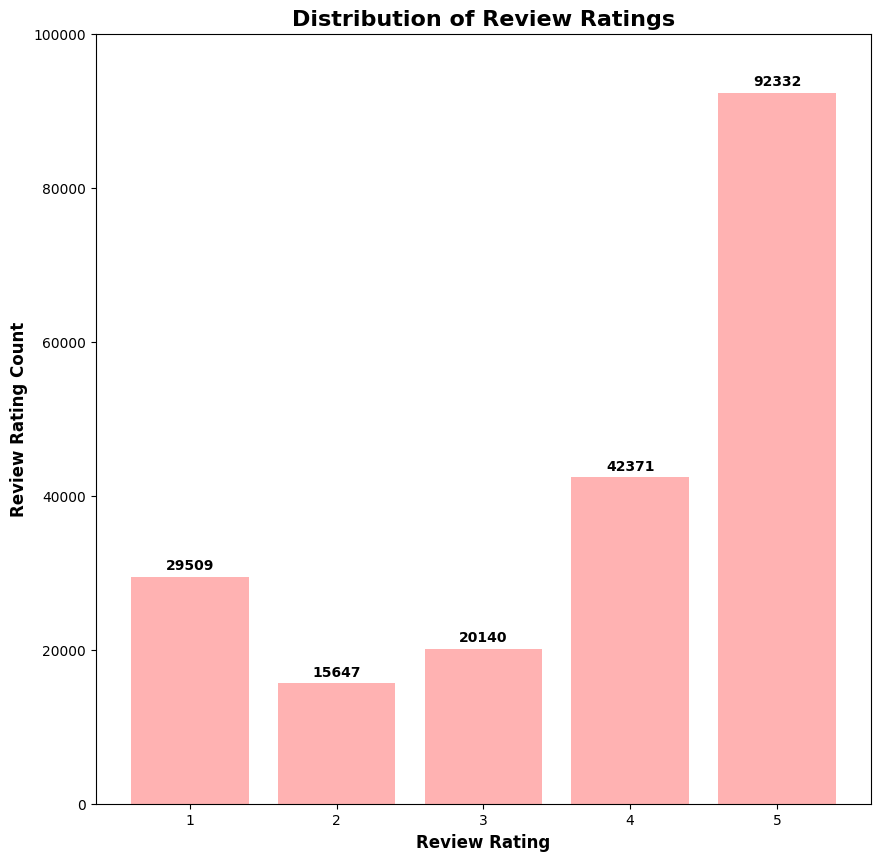

In [28]:
fig, ax=plt.subplots(figsize=(10,10))

#plot bar chart
bars = ax.bar(sampled_df['review_rating'].value_counts().index, sampled_df['review_rating'].value_counts().values, color='red', alpha=.3)

#get bar labels
ax.bar_label(bars, padding=3, fontweight='bold')

#plot axis labels and title
ax.set_xlabel('Review Rating', fontweight='bold', fontsize=12)
ax.set_ylabel('Review Rating Count', fontweight='bold', fontsize=12)
ax.set_title('Distribution of Review Ratings', fontweight='bold', fontsize=16)

#expand the y axis
ax.set_ylim(0,100000)

#plot
plt.show()

The review ratings data is skewed to the left with most of the data being concentrated in the 4-5 stars. This makes sense the mean of the sampled review ratings is is 3.7 which is closer to the upper bound (5) of the review ratings than the lower bound (1). I don't think the uneveness of the distribution should dramatically affect my analysis since I am performing an NLP assessment on the ratings. This is just practice on visualizations.


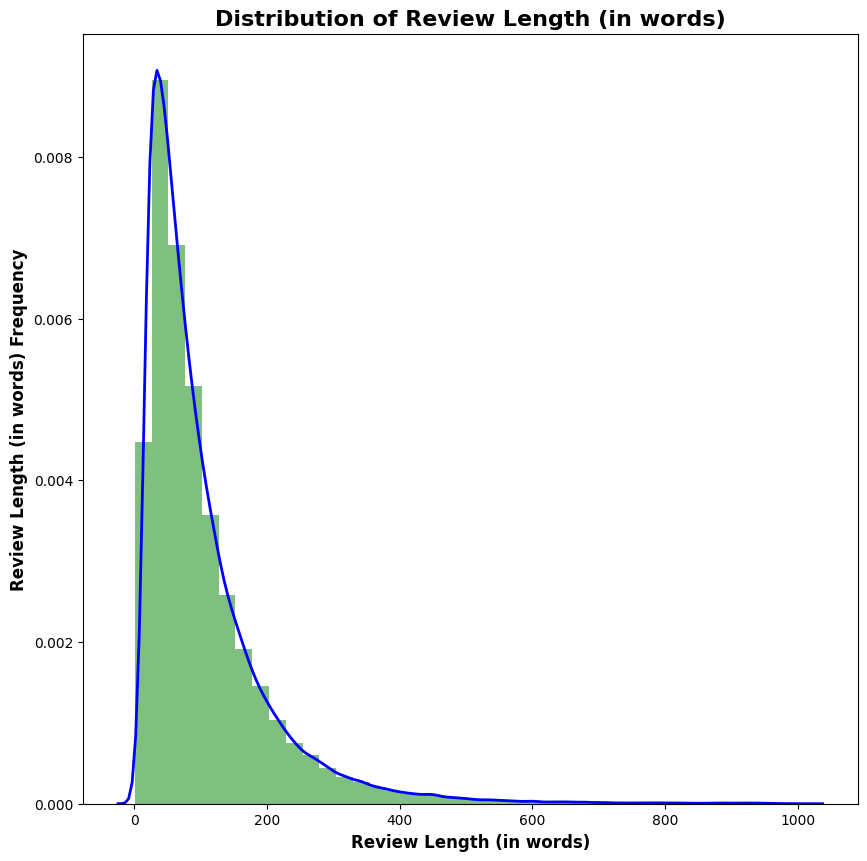

In [29]:
fig, ax = plt.subplots(figsize=(10,10))

data= sampled_df['review_length']
hist= ax.hist(data, bins= 40, alpha=.5, color='g', density=True)

ax.set_xlabel('Review Length (in words)', fontweight='bold', fontsize=12)
ax.set_ylabel('Review Length (in words) Frequency', fontweight='bold', fontsize=12)
ax.set_title('Distribution of Review Length (in words)', fontweight='bold', fontsize=16)

sns.kdeplot(data, ax=ax, color='blue', linewidth=2)

plt.show()





In [55]:
sampled_df['review_length'].describe()

count    199999.000000
mean        104.070615
std          97.318565
min           1.000000
25%          41.000000
50%          74.000000
75%         133.000000
max        1012.000000
Name: review_length, dtype: float64

Due to the heavily tailed nature of the review length, I am going to filter it from 15-500 words to remove the outliers on both sides. For my NLP pipeline this will ensure that the reviews that I input have enough context to come to a concrete conclusion and to limit latency for large reviews.


<Axes: >

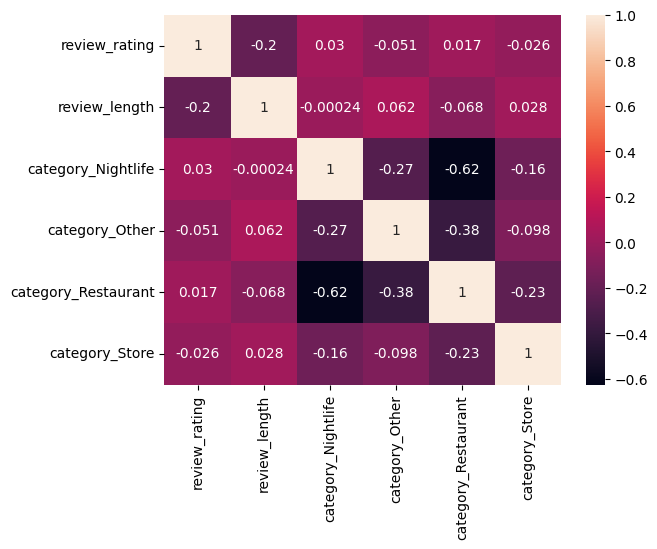

In [30]:
data=sampled_df[['category', 'review_rating', 'review_length']]

encoded_data = pd.get_dummies(data, columns = ['category'], drop_first=True, dtype=int)


sns.heatmap(encoded_data.corr(), annot=True)



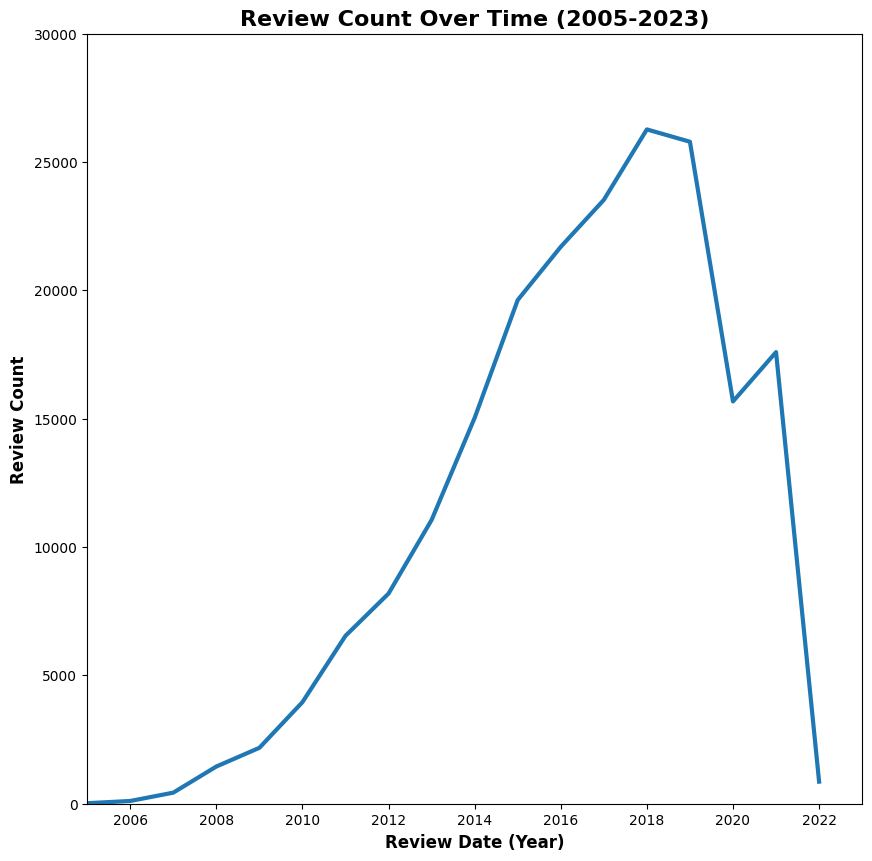

In [51]:
plt.figure(figsize=(10,10))
sns.lineplot(x=sampled_df['review_date'].dt.year.value_counts().index, y=sampled_df['review_date'].dt.year.value_counts().values, linewidth=3)

plt.xlabel('Review Date (Year)', fontweight='bold', fontsize=12)
plt.ylabel('Review Count', fontweight= 'bold', fontsize=12)
plt.title('Review Count Over Time (2005-2023)', fontweight='bold', fontsize=16)

plt.ylim(0,30000)
plt.xlim(2005, 2023)
plt.show()

The sampled data's review timeline seems to peak around 2018-2019. A sharp decline follows after the peak probably due to COVID-19 and most businesses closing or reducing their working hours during that time. Due to the lower amounts of open businesses, less reviews were likely made. However, there is a sharp increase around 2021 which might be in response to COVID restrictions. People might have been leaving reviews of businesses the complied or broke the COVID restriction rules.

In [54]:
sampled_df.drop('categories', inplace=True, axis=1)
sampled_df.to_csv('/Users/spennyfinn/Documents/Projects/NLP/data/ratings.csv')